In [128]:
from collections import defaultdict
from pathlib import Path
import csv
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_PATH = Path("results/benchmark_results.csv")

df = pd.read_csv(RESULTS_PATH)

df["N"] = pd.to_numeric(df["N"], errors="coerce")
df["P"] = pd.to_numeric(df["P"], errors="coerce")
df["PARTITION_TIME"] = pd.to_numeric(df["PARTITION_TIME"], errors="coerce")
df["GLOBAL_TIME"] = pd.to_numeric(df["GLOBAL_TIME"], errors="coerce")

exec_type_names = sorted(df["EXEC_TYPE"].dropna().unique())
exec_type_palette = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan",
]
exec_type_colors = {
    exec_type: exec_type_palette[idx % len(exec_type_palette)]
    for idx, exec_type in enumerate(exec_type_names)
}

print(f"[Loaded {df.shape[0]} different runs from {RESULTS_PATH}]\n")
print("Distinct values for each column:")
print(f"  EXEC_TYPE: {df['EXEC_TYPE'].unique()}")
print(f"  HASH: {df['HASH'].unique()}")
print(f"  N: {df['N'].unique()}")
print(f"  P: {df['P'].unique()}")

[Loaded 135 different runs from results/benchmark_results.csv]

Distinct values for each column:
  EXEC_TYPE: ['plain_novec' 'plain_vec' 'avx2']
  HASH: ['mask']
  N: [10000000]
  P: [  16   32   64  128  256  512 1024 2048 4096]


# Checksum validation

In [129]:
summary_rows = []
df_grouped = df.groupby(["N", "P", "HASH"])
valid_counter = 0
for (N, P, HASH), subdf in df_grouped:
    checksums = subdf["CHECKSUM"].unique()
    is_valid = len(checksums) == 1
    valid_counter += 1 if is_valid else 0

    summary_rows.append({
        "N": N,
        "P": P,
        "HASH": HASH,
        "N_CHECKSUMS": len(checksums),
        "CHECKSUMS": ", ".join(map(str, checksums))
    })

if valid_counter == df_grouped.ngroups:
    print(f"[OK] All groups have a single unique checksum")
else:
    print(f"[FAIL] Only {valid_counter}/{df_grouped.ngroups} groups have a single unique checksum")

checksum_validation_df = pd.DataFrame(summary_rows)
checksum_validation_df


[OK] All groups have a single unique checksum


,N,P,HASH,N_CHECKSUMS,CHECKSUMS
0,10000000,16,mask,1,646785527683847652617387416037230238153
1,10000000,32,mask,1,42867239462688925741090953971268491417
2,10000000,64,mask,1,180344641600089295815274362764746307001
3,10000000,128,mask,1,82809270534509212616816454287959339385
4,10000000,256,mask,1,1314774605202903785416717757788193993593
5,10000000,512,mask,1,536831656504787356614739286363186079865
6,10000000,1024,mask,1,178937207405185879346991956829105386105
7,10000000,2048,mask,1,174751143964903068612950250125392416377
8,10000000,4096,mask,1,118826605224740459825505141072278363769


# Averaging

In [130]:
group_columns = ["N", "P", "HASH", "EXEC_TYPE", "CHECKSUM"]
avg_columns = [
    col for col in df.columns
    if col not in group_columns and pd.api.types.is_numeric_dtype(df[col])
]

# Collapse repeated runs and keep one averaged row for each stable configuration
stable_avg_df = (
    df.groupby(group_columns, as_index=False)
    .agg({col: "mean" for col in avg_columns})
    .rename(columns={col: f"AVG_{col}" for col in avg_columns})
    .sort_values(group_columns)
    .reset_index(drop=True)
)

stable_avg_df.head(10)


,N,P,HASH,EXEC_TYPE,CHECKSUM,AVG_THROUGHPUT,AVG_PARTITION_TIME,AVG_GLOBAL_TIME
0,10000000,16,mask,avx2,646785527683847652617387416037230238153,1.343701e+09,0.014890,1.814146
1,10000000,16,mask,plain_novec,646785527683847652617387416037230238153,3.603742e+08,0.055526,2.156520
2,10000000,16,mask,plain_vec,646785527683847652617387416037230238153,7.691899e+08,0.026040,1.829818
3,10000000,32,mask,avx2,42867239462688925741090953971268491417,1.344156e+09,0.014886,1.799182
4,10000000,32,mask,plain_novec,42867239462688925741090953971268491417,3.595182e+08,0.055656,1.875286
5,10000000,32,mask,plain_vec,42867239462688925741090953971268491417,7.762302e+08,0.025792,1.819124
6,10000000,64,mask,avx2,180344641600089295815274362764746307001,1.346248e+09,0.014860,1.809624
7,10000000,64,mask,plain_novec,180344641600089295815274362764746307001,3.595080e+08,0.055668,1.828604
8,10000000,64,mask,plain_vec,180344641600089295815274362764746307001,7.690071e+08,0.026058,1.827418
9,10000000,128,mask,avx2,82809270534509212616816454287959339385,1.340412e+09,0.014928,1.795570


# Speedup

In [131]:
# Use the averaged throughput of plain_novec as the reference for speedup.
baseline_exec_type = "plain_novec"
baseline_df = (
    stable_avg_df[stable_avg_df["EXEC_TYPE"] == baseline_exec_type][
        ["N", "P", "HASH", "CHECKSUM", "AVG_THROUGHPUT"]
    ]
    .rename(columns={"AVG_THROUGHPUT": "BASELINE_AVG_THROUGHPUT"})
)
speedup_avg_df = stable_avg_df.merge(
    baseline_df,
    on=["N", "P", "HASH", "CHECKSUM"],
    how="left",
)
speedup_avg_df["SPEEDUP"] = (
    round(speedup_avg_df["AVG_THROUGHPUT"] / speedup_avg_df["BASELINE_AVG_THROUGHPUT"], 2)
)

speedup_avg_df.head(10)

,N,P,HASH,EXEC_TYPE,CHECKSUM,AVG_THROUGHPUT,AVG_PARTITION_TIME,AVG_GLOBAL_TIME,BASELINE_AVG_THROUGHPUT,SPEEDUP
0,10000000,16,mask,avx2,646785527683847652617387416037230238153,1.343701e+09,0.014890,1.814146,3.603742e+08,3.73
1,10000000,16,mask,plain_novec,646785527683847652617387416037230238153,3.603742e+08,0.055526,2.156520,3.603742e+08,1.00
2,10000000,16,mask,plain_vec,646785527683847652617387416037230238153,7.691899e+08,0.026040,1.829818,3.603742e+08,2.13
3,10000000,32,mask,avx2,42867239462688925741090953971268491417,1.344156e+09,0.014886,1.799182,3.595182e+08,3.74
4,10000000,32,mask,plain_novec,42867239462688925741090953971268491417,3.595182e+08,0.055656,1.875286,3.595182e+08,1.00
5,10000000,32,mask,plain_vec,42867239462688925741090953971268491417,7.762302e+08,0.025792,1.819124,3.595182e+08,2.16
6,10000000,64,mask,avx2,180344641600089295815274362764746307001,1.346248e+09,0.014860,1.809624,3.595080e+08,3.74
7,10000000,64,mask,plain_novec,180344641600089295815274362764746307001,3.595080e+08,0.055668,1.828604,3.595080e+08,1.00
8,10000000,64,mask,plain_vec,180344641600089295815274362764746307001,7.690071e+08,0.026058,1.827418,3.595080e+08,2.14
9,10000000,128,mask,avx2,82809270534509212616816454287959339385,1.340412e+09,0.014928,1.795570,3.628716e+08,3.69


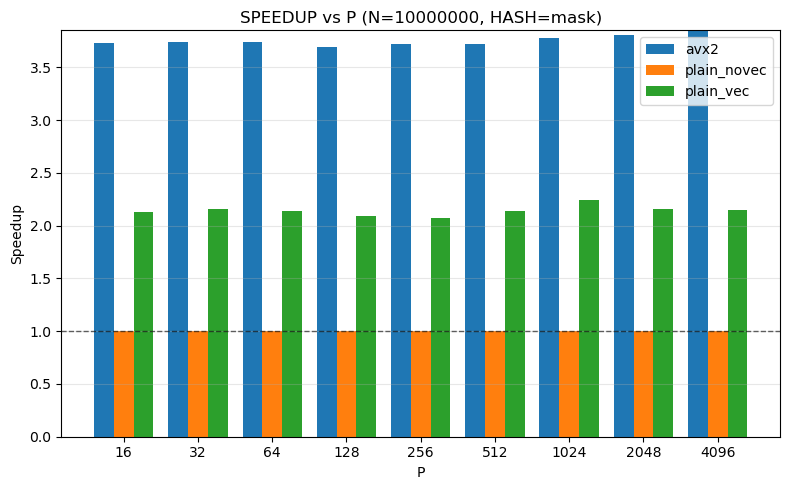

In [132]:
GLOBAL_SPEEDUP_YMAX = speedup_avg_df["SPEEDUP"].max()
for (fixed_N, fixed_HASH), subdf in speedup_avg_df.groupby(["N", "HASH"]):
    plot_df = subdf.sort_values(["P", "EXEC_TYPE"])

    p_values = sorted(plot_df["P"].unique())
    x_positions = list(range(len(p_values)))
    exec_types = sorted(plot_df["EXEC_TYPE"].dropna().unique())

    if not exec_types:
        continue

    bar_width = 0.8 / len(exec_types)

    plt.figure(figsize=(8, 5))

    for idx, exec_type in enumerate(exec_types):
        g = plot_df[plot_df["EXEC_TYPE"] == exec_type].sort_values("P")
        values_by_p = g.set_index("P")["SPEEDUP"].to_dict()
        heights = [values_by_p.get(p, float("nan")) for p in p_values]
        offsets = [
            x + (idx - (len(exec_types) - 1) / 2) * bar_width
            for x in x_positions
        ]

        plt.bar(
            offsets,
            heights,
            width=bar_width,
            color=exec_type_colors.get(exec_type, "tab:gray"),
            label=exec_type,
        )

    if pd.notna(GLOBAL_SPEEDUP_YMAX):
        plt.ylim(0, GLOBAL_SPEEDUP_YMAX)

    plt.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.6)
    plt.xticks(x_positions, p_values)
    plt.xlabel("P")
    plt.ylabel("Speedup")
    plt.title(f"SPEEDUP vs P (N={fixed_N}, HASH={fixed_HASH})")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Throughput

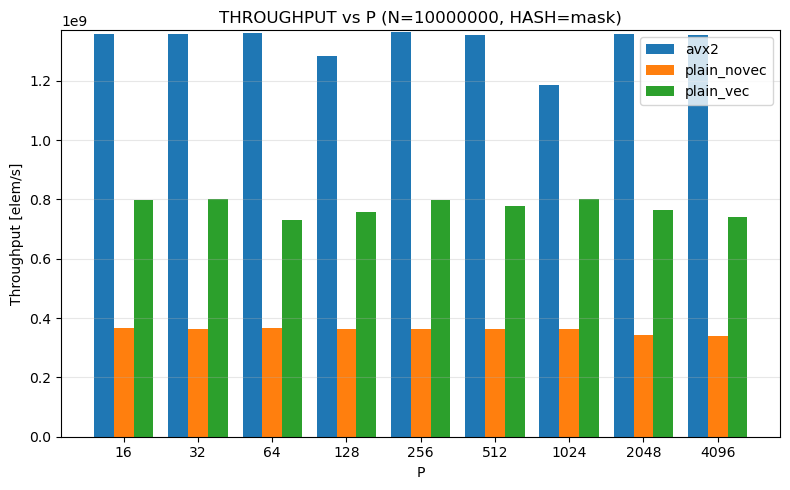

In [133]:
GLOBAL_THROUGHPUT_YMAX = df["THROUGHPUT"].max()
for (fixed_N, fixed_HASH), subdf in df.groupby(["N", "HASH"]):
    plt.figure(figsize=(8, 5))

    p_values = sorted(subdf["P"].unique())
    x_positions = list(range(len(p_values)))
    exec_types = sorted(subdf["EXEC_TYPE"].dropna().unique())

    if not exec_types:
        continue

    bar_width = 0.8 / len(exec_types)
    max_candidates = []

    for idx, exec_type in enumerate(exec_types):
        g = subdf[subdf["EXEC_TYPE"] == exec_type].sort_values("P")
        values_by_p = g.set_index("P")["THROUGHPUT"].to_dict()
        heights = [values_by_p.get(p, float("nan")) for p in p_values]
        offsets = [
            x + (idx - (len(exec_types) - 1) / 2) * bar_width
            for x in x_positions
        ]

        for value in heights:
            if pd.notna(value):
                max_candidates.append(value)

        plt.bar(
            offsets,
            heights,
            width=bar_width,
            color=exec_type_colors.get(exec_type, "tab:gray"),
            label=exec_type,
        )

    if pd.notna(GLOBAL_THROUGHPUT_YMAX):
        plt.ylim(0, GLOBAL_THROUGHPUT_YMAX)

    plt.xticks(x_positions, p_values)
    plt.xlabel("P")
    plt.ylabel("Throughput [elem/s]")
    plt.title(f"THROUGHPUT vs P (N={fixed_N}, HASH={fixed_HASH})")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
